<a href="https://colab.research.google.com/github/lisa11323/Organic-food/blob/main/analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import os


folder_path = "/content/drive/My Drive/MDV/"
file_paths = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.xlsx')]
combined_df = pd.DataFrame()
for file in file_paths:
    df = pd.read_excel(file)
    combined_df = pd.concat([combined_df, df], ignore_index=True)
combined_df.to_excel("/content/drive/My Drive/MDV/combined_brands_data.xlsx", index=False)

print("所有文件已成功合并并保存为 combined_brands_data.xlsx")


所有文件已成功合并并保存为 combined_brands_data.xlsx


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
!pip install pyLDAvis

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
import pandas as pd

import nltk
from nltk import PorterStemmer
from nltk.corpus import stopwords
from nltk.tag import pos_tag
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

import pyLDAvis.lda_model
import gensim
from gensim import corpora
from gensim.models import Phrases, CoherenceModel
from gensim.models.phrases import Phraser

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import joblib

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('omw-1.4')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-dat

True

In [ ]:
data = pd.read_excel('/content/drive/MyDrive/MDV/combined_brands_datalie.xlsx')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
texts = data['tags'].values
texts = texts.tolist()

print(len(texts))

14503


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

# 下载 NLTK 数据包
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')

# 清洗文本函数
def clean_text(text):
    # 移除多余空格、换行符、重复标点符号
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[\n\r]+', ' ', text)
    text = re.sub(r'[.?!]+', '.', text)
    text = re.sub(r'[^\w\s]', '', text)  # 移除标点符号
    return text.lower()

# 去除 Emoji 的函数
def remove_emojis(text):
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002500-\U00002BEF"  # chinese char
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\u2640-\u2642"
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"  # dingbats
        u"\u3030"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

# 主清洗函数
def preprocess_text(text):
    text = clean_text(text)
    text = remove_emojis(text)
    return text



/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
# 清洗和处理所有标签数据
processed_texts = [preprocess_text(text) for text in texts]
print(f"Sample processed text: {processed_texts[:5]}")

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Sample processed text: ['design color upsidefoods', 'foodtech swiggy getir weee lanza upsidefoods', 'cellularagriculture upsidefoods cultivatedmeat', 'labgrownmeat labgrownchicken labradors blacklabs chocolatelabs goldenlabs labradorretrivers animalcruelty chickenfarms chickenfactory dailystoopid labgrownmeats cellculturedmeat cellculturedmeats ethicalmeat sustainablefuture upsidefoods goodmeatinc cellularagriculture', 'upsidefoods cultivatedmeat']


In [ ]:
import nltk
try:
    nltk.data.find('tokenizers/punkt')
    print("punkt 数据包加载成功！")
except LookupError:
    print("punkt 数据包未找到！")

punkt 数据包加载成功！


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
pip install --upgrade nltk

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

lemmatizer = WordNetLemmatizer()

# 获取单词的词性标记
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return 'a'  # 形容词
    elif tag.startswith('V'):
        return 'v'  # 动词
    elif tag.startswith('N'):
        return 'n'  # 名词
    elif tag.startswith('R'):
        return 'r'  # 副词
    else:
        return 'n'  # 默认使用名词

# 分词和词形还原函数
def tokenize_and_lemmatize(text):
    tokens = word_tokenize(text)  # 分词
    pos_tags = pos_tag(tokens)  # 词性标注
    lemmatized_tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]
    return lemmatized_tokens

# 对处理后的文本进行分词和词形还原
tokenized_texts = [tokenize_and_lemmatize(text) for text in processed_texts]
print(f"Sample tokenized text: {tokenized_texts[:5]}")

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Sample tokenized text: [['design', 'color', 'upsidefoods'], ['foodtech', 'swiggy', 'getir', 'weee', 'lanza', 'upsidefoods'], ['cellularagriculture', 'upsidefoods', 'cultivatedmeat'], ['labgrownmeat', 'labgrownchicken', 'labrador', 'blacklabs', 'chocolatelabs', 'goldenlabs', 'labradorretrivers', 'animalcruelty', 'chickenfarms', 'chickenfactory', 'dailystoopid', 'labgrownmeats', 'cellculturedmeat', 'cellculturedmeats', 'ethicalmeat', 'sustainablefuture', 'upsidefoods', 'goodmeatinc', 'cellularagriculture'], ['upsidefoods', 'cultivatedmeat']]


In [ ]:
stop_words = set(stopwords.words('english'))

# 去除停用词
filtered_texts = [[word for word in tokens if word not in stop_words] for tokens in tokenized_texts]
print(f"Sample filtered text: {filtered_texts[:5]}")

Sample filtered text: [['design', 'color', 'upsidefoods'], ['foodtech', 'swiggy', 'getir', 'weee', 'lanza', 'upsidefoods'], ['cellularagriculture', 'upsidefoods', 'cultivatedmeat'], ['labgrownmeat', 'labgrownchicken', 'labrador', 'blacklabs', 'chocolatelabs', 'goldenlabs', 'labradorretrivers', 'animalcruelty', 'chickenfarms', 'chickenfactory', 'dailystoopid', 'labgrownmeats', 'cellculturedmeat', 'cellculturedmeats', 'ethicalmeat', 'sustainablefuture', 'upsidefoods', 'goodmeatinc', 'cellularagriculture'], ['upsidefoods', 'cultivatedmeat']]


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# 将预处理后的数据重新整合为 DataFrame
data['Processed_Tags'] = [' '.join(tokens) for tokens in filtered_texts]

# 按品牌分组 (假设 'brand' 列存在)
if 'brand' in data.columns:
    grouped_data = data.groupby('brand')['Processed_Tags'].apply(list).reset_index()
    print(grouped_data.head())
else:
    print("Warning: 'brand' column not found, unable to group data.")

             brand                                     Processed_Tags
0       alephfarms  [, cravechange, vegnews leonardodicaprio leodi...
1       beyondmeat  [stayathomechallenge magicofthemonth vfxcompan...
2  impossiblefoods  [importexpo ciie impossiblefoods impossiblefoo...
3      upsidefoods  [design color upsidefoods, foodtech swiggy get...


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


#빈도수

In [ ]:
output_path = '/content/drive/MyDrive/MDV/preprocessed_data.csv'
data.to_csv(output_path, index=False)
print(f"Preprocessed data saved to {output_path}")

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Preprocessed data saved to /content/drive/MyDrive/MDV/preprocessed_data.csv


In [ ]:
from collections import Counter
# 确保 'Processed_Tags' 列中的所有元素为字符串并处理空值
data['Processed_Tags'] = data['Processed_Tags'].fillna('')  # 填充空值
data['Processed_Tags'] = data['Processed_Tags'].astype(str)  # 转换为字符串类型

# 按品牌分组并合并标签
brand_tags = data.groupby('brand')['Processed_Tags'].apply(lambda x: ' '.join(x)).reset_index()

# 计算每个品牌标签的频度
brand_tags['Tag_Frequency'] = brand_tags['Processed_Tags'].apply(lambda x: Counter(x.split()))

# 查看某个品牌的标签频度
print(brand_tags['Tag_Frequency'].head())

0    {'cravechange': 34, 'vegnews': 34, 'leonardodi...
1    {'stayathomechallenge': 1, 'magicofthemonth': ...
2    {'importexpo': 3, 'ciie': 3, 'impossiblefoods'...
3    {'design': 85, 'color': 85, 'upsidefoods': 542...
Name: Tag_Frequency, dtype: object


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
print(brand_tags['Processed_Tags'].head())  # 查看部分标签

0     cravechange vegnews leonardodicaprio leodicap...
1    stayathomechallenge magicofthemonth vfxcompany...
2    importexpo ciie impossiblefoods impossiblefood...
3    design color upsidefoods foodtech swiggy getir...
Name: Processed_Tags, dtype: object


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# 检查数据格式
print(brand_tags[['brand', 'Processed_Tags']].head())


             brand                                     Processed_Tags
0       alephfarms   cravechange vegnews leonardodicaprio leodicap...
1       beyondmeat  stayathomechallenge magicofthemonth vfxcompany...
2  impossiblefoods  importexpo ciie impossiblefoods impossiblefood...
3      upsidefoods  design color upsidefoods foodtech swiggy getir...


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


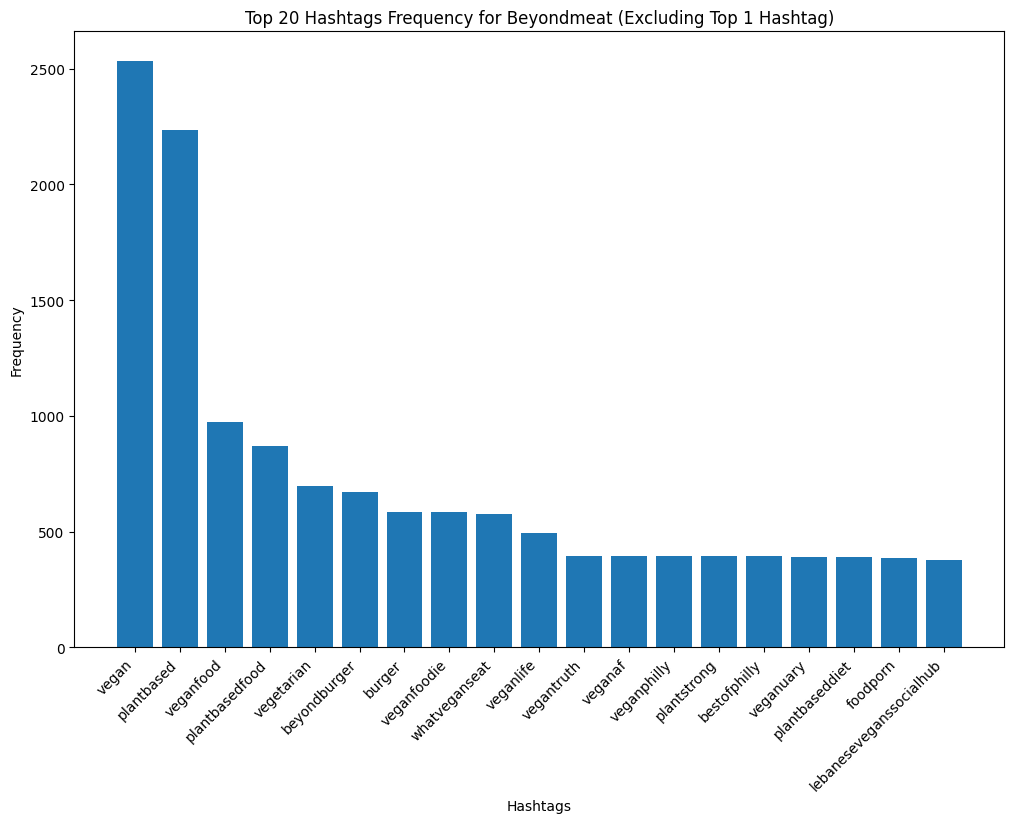

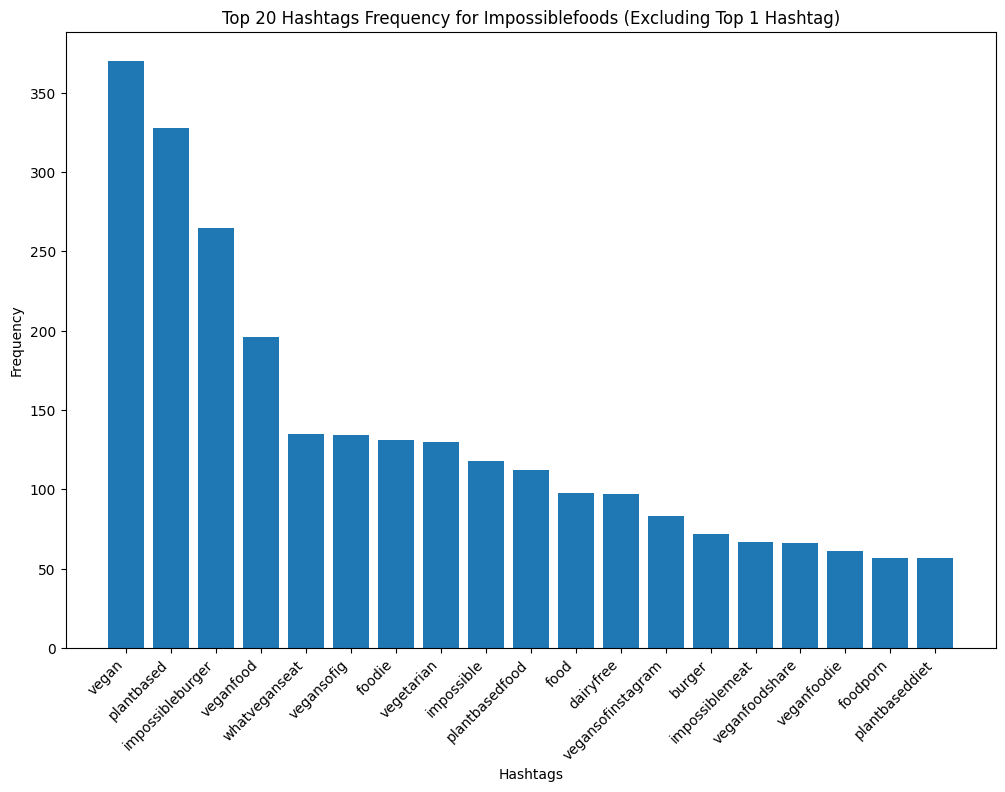

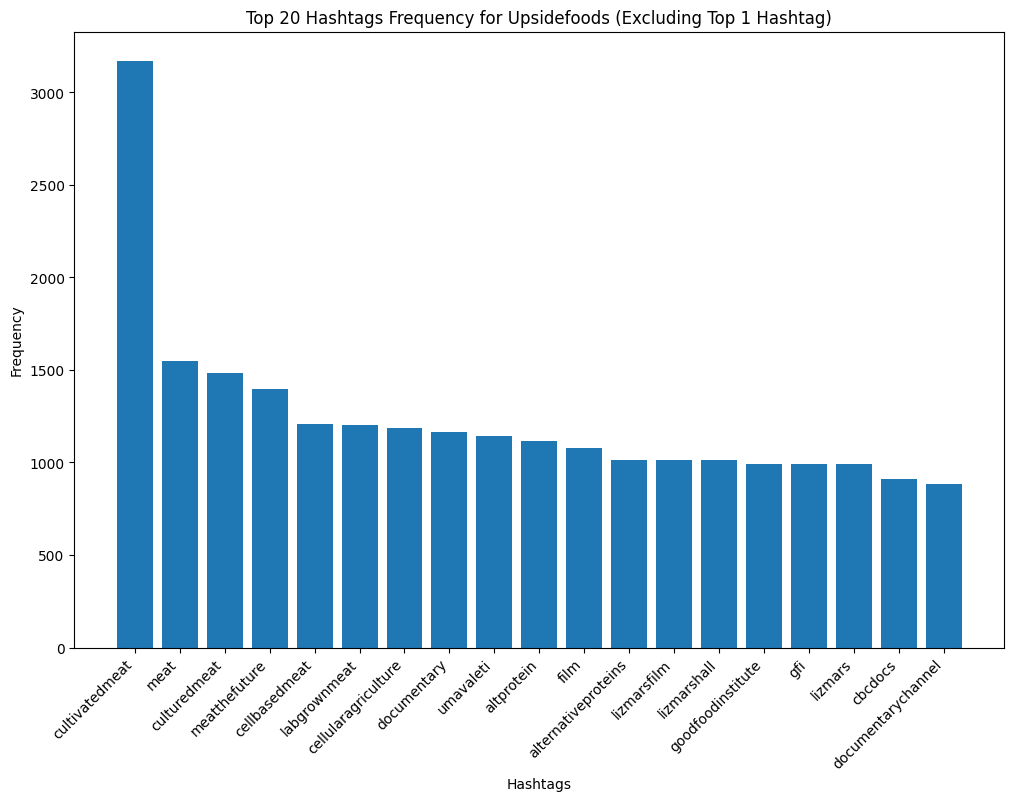

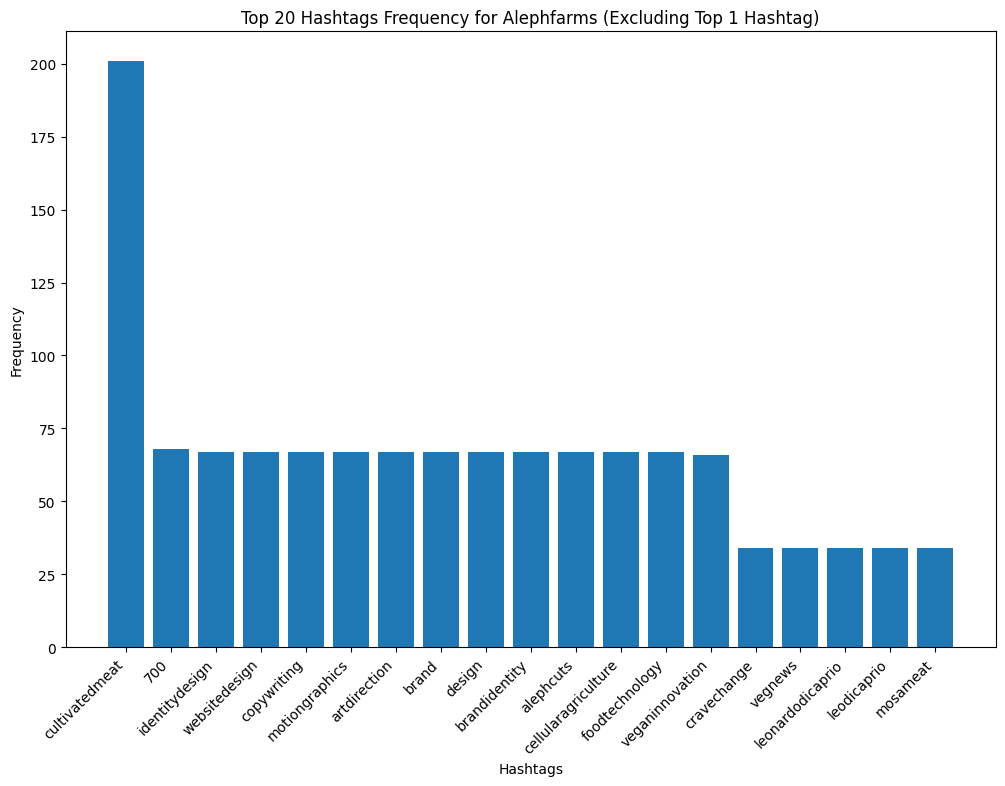

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# 假设您有一个包含处理后标签的列表，brand_tags['Processed_Tags'] 包含了每个标签字符串
# 例如，brand_tags['Processed_Tags'] = ['#beyondmeat #vegan', '#impossiblefoods #plantbased']

# 品牌列表
brands_list = ['beyondmeat', 'impossiblefoods', 'upsidefoods', 'alephfarms']

# 创建一个字典来存储每个品牌的标签
brand_hashtags = {brand: [] for brand in brands_list}

# 提取每个品牌的标签
for index, row in brand_tags.iterrows():
    brand_name = row['brand'].lower()  # 获取品牌名称并转为小写
    tags = row['Processed_Tags'].split()  # 分割标签字符串为单个标签
    if brand_name in brands_list:
        for tag in tags:
            if tag.startswith(''):  # 只考虑以 '#' 开头的标签
                brand_hashtags[brand_name].append(tag)  # 保存标签

# 绘制每个品牌的标签频度图
for brand, hashtags in brand_hashtags.items():
    hashtag_counts = Counter(hashtags)  # 统计标签频度
    top_hashtags = hashtag_counts.most_common(20)  # 获取前20个常用标签

    # 过滤掉Top 1标签
    filtered_top_hashtags = top_hashtags[1:]  # 去掉Top 1标签

    # 提取标签和频度
    labels, values = zip(*filtered_top_hashtags)

    # 可视化每个品牌的标签频度
    plt.figure(figsize=(12, 8))
    plt.bar(labels, values)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Top 20 Hashtags Frequency for {brand.capitalize()} (Excluding Top 1 Hashtag)')
    plt.xlabel('Hashtags')
    plt.ylabel('Frequency')
    plt.show()


#년도별 해시태그 사용량


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


                                      Processed_Tags  year
0                           design color upsidefoods  2021
1       foodtech swiggy getir weee lanza upsidefoods  2022
2     cellularagriculture upsidefoods cultivatedmeat  2024
3  labgrownmeat labgrownchicken labrador blacklab...  2023
4                         upsidefoods cultivatedmeat  2022
  Processed_Tags  year
0         design  2021
0          color  2021
0    upsidefoods  2021
1       foodtech  2022
1         swiggy  2022
  Processed_Tags  year
0    upsidefoods  2021
1    upsidefoods  2022
2    upsidefoods  2024
3    upsidefoods  2023
4    upsidefoods  2022
Processed_Tags  alephfarms  beyondmeat  impossiblefoods  upsidefoods
year                                                                
2018                     0           0                0           21
2019                     0           0                3            0
2020                     0           1                0            0
2021                    5

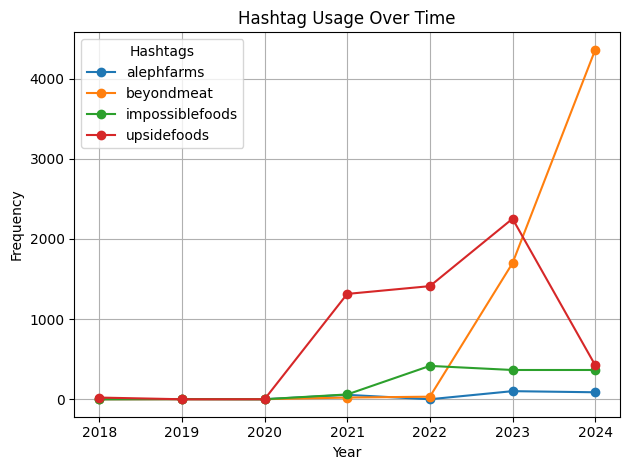

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据
output_path = '/content/drive/MyDrive/MDV/preprocessed_data.csv'
data = pd.read_csv(output_path)

# 确保 'date' 列已经是日期格式
data['date'] = pd.to_datetime(data['date'])

# 提取年份
data['year'] = data['date'].dt.year

# 打印数据检查
print(data[['Processed_Tags', 'year']].head())

# 处理 NaN 值，确保 'Processed_Tags' 列是字符串
data['Processed_Tags'] = data['Processed_Tags'].fillna('')

# 将 'Processed_Tags' 转换为字符串并按空格分隔为列表
data['Processed_Tags'] = data['Processed_Tags'].astype(str).apply(lambda x: x.split())

# 使用 explode 拆分标签
exploded_tags = data.explode('Processed_Tags')

# 打印检查 explode 后的数据
print(exploded_tags[['Processed_Tags', 'year']].head())

# 指定你想分析的四个标签
hashtags = ['beyondmeat', 'impossiblefoods', 'upsidefoods', 'alephfarms']

# 过滤出包含这些标签的行
filtered_df = exploded_tags[exploded_tags['Processed_Tags'].isin(hashtags)]

# 检查过滤后的数据
print(filtered_df[['Processed_Tags', 'year']].head())

# 计算每个标签在每年的出现次数
hashtag_yearly = filtered_df.groupby(['year', 'Processed_Tags']).size().unstack(fill_value=0)

# 打印按年份统计的标签出现次数
print(hashtag_yearly)

# 可视化标签随时间的变化
if not hashtag_yearly.empty:
    hashtag_yearly.plot(kind='line', marker='o')
    plt.title('Hashtag Usage Over Time')
    plt.xlabel('Year')
    plt.ylabel('Frequency')
    plt.legend(title='Hashtags', loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No data available for the selected hashtags.")

#Eigenvector Centrality


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


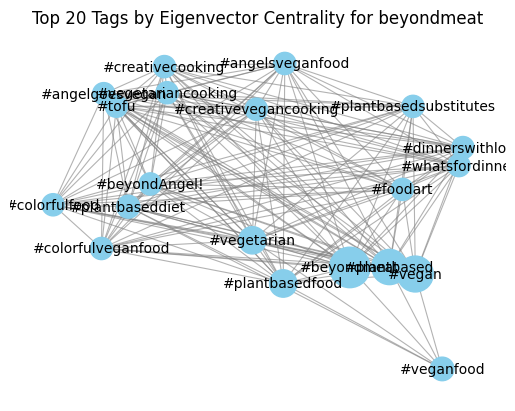

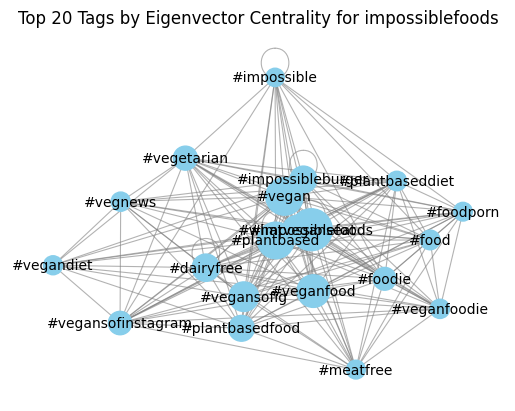

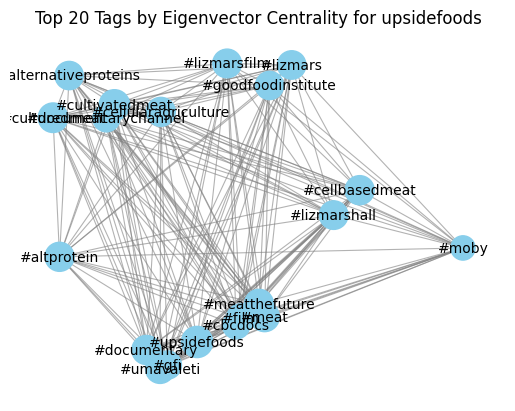

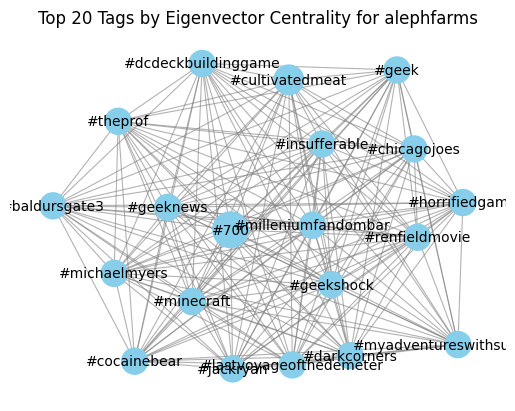

Results saved to /content/drive/MyDrive/MDV/tag_centrality_results.csv


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

# 读取数据
df = pd.read_csv('/content/drive/MyDrive/MDV/preprocessed_data.csv')  # 替换为您的文件路径

# 初始化存储结果的字典
brand_centrality = {}

# 目标品牌列表
brands = ['beyondmeat', 'impossiblefoods', 'upsidefoods', 'alephfarms']

for brand in brands:
    G = nx.Graph()  # 为每个品牌创建一个新的图

    # 过滤出特定品牌的数据
    df_brand = df[df['brand'] == brand]

    # 遍历每一行的tags，构建标签网络
    for tags in df_brand['tags']:
        tags = eval(tags)  # 将字符串转换为列表
        for tag1, tag2 in combinations(tags, 2):  # 创建标签的所有组合
            if G.has_edge(tag1, tag2):
                G[tag1][tag2]['weight'] += 1  # 如果已经有边，增加权重
            else:
                G.add_edge(tag1, tag2, weight=1)  # 否则，添加一条边

    # 计算每个节点的Eigenvector Centrality
    centrality = nx.eigenvector_centrality(G, weight='weight')

    # 按中央性值排序，选择前20个最具影响力的标签
    top_centrality = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:20]
    top_labels = [x[0] for x in top_centrality]

    # 将结果存储在字典中
    brand_centrality[brand] = top_centrality

    # 创建子图，仅包含前20个标签
    subgraph = G.subgraph(top_labels)

    # 设置节点位置
    pos = nx.spring_layout(subgraph, k=0.15, iterations=20)

    # 绘制节点
    node_sizes = [centrality[node] * 2000 for node in subgraph.nodes()]
    nx.draw_networkx_nodes(subgraph, pos, node_size=node_sizes, node_color='skyblue')

    # 绘制标签
    nx.draw_networkx_labels(subgraph, pos, font_size=10, font_color='black')

    # 绘制边
    nx.draw_networkx_edges(subgraph, pos, width=0.8, alpha=0.6, edge_color='gray')

    # 绘制图形
    plt.title(f'Top 20 Tags by Eigenvector Centrality for {brand}')
    plt.axis('off')  # 去掉坐标轴

    # 保存图像
    plt.savefig(f'/content/drive/MyDrive/MDV/{brand}_network_visualization.png')
    plt.show()

# 保存中央性值到 CSV 文件
results = []
for brand, centrality_data in brand_centrality.items():
    for tag, value in centrality_data:
        results.append({'Brand': brand, 'Tag': tag, 'Centrality': value})

results_df = pd.DataFrame(results)
output_path = '/content/drive/MyDrive/MDV/tag_centrality_results.csv'
results_df.to_csv(output_path, index=False)
print(f'Results saved to {output_path}')


#sentiment analysis

In [ ]:
import pandas as pd
import re
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# 下载 NLTK 数据包
nltk.download('vader_lexicon')

# 读取数据
df = pd.read_csv('/content/drive/MyDrive/MDV/preprocessed_data.csv')


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
import re
import string
import pandas as pd

# 去除 Emoji 的函数
def remove_emojis(text):
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"  # 表情符号
        u"\U0001F300-\U0001F5FF"  # 符号与图形
        u"\U0001F680-\U0001F6FF"  # 交通与地图符号
        u"\U0001F1E0-\U0001F1FF"  # 国旗 (iOS)
        u"\U00002500-\U00002BEF"  # 汉字字符
        u"\U00002702-\U000027B0"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642"
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"  # dingbats
        u"\u3030"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

# 清洗文本函数
def clean_text(text):
    punctuation_and_symbols = string.punctuation + "‘’“”" + '-'

    # 去除多余空格
    text = re.sub(' +', ' ', str(text))  # 将多个空格转换为一个空格
    text = re.sub('\n', '', text)  # 去除换行符
    text = re.sub('\\.+|\\!+|\\?+', '. ', text)  # 将多个标点符号替换为单个句点
    text = re.sub('\'ve', ' have', text)  # 转换缩写形式
    text = re.sub(r'\d+', '', text)  # 移除数字
    text = remove_emojis(text)  # 去除表情符号
    text = text.translate(str.maketrans('', '', punctuation_and_symbols))  # 移除标点符号与特殊字符
    text = text.lower()  # 转为小写
    return text

# 假设您已读取数据到 df 中
df = pd.read_csv('/content/drive/MyDrive/MDV/preprocessed_data.csv')

# 应用清洗函数到 'content' 列
df['cleaned_content'] = df['content'].apply(clean_text)

# 检查清洗结果
print(df[['content', 'cleaned_content']].head())

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


                                             content  \
0  When we set out on our mission to make meat a ...   
1  #foodtech #swiggy #getir #weee #lanza #upsidef...   
2  It has been almost 30 years since I have eaten...   
3  Follow @daily_stoopid for more science news---...   
4  Y’all know me as a maker and baby knitting des...   

                                     cleaned_content  
0  when we set out on our mission to make meat a ...  
1       foodtech swiggy getir weee lanza upsidefoods  
2  it has been almost  years since i have eaten c...  
3  follow dailystoopid for more science newslabgr...  
4  yall know me as a maker and baby knitting desi...  


In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# 下载 NLTK 停用词库
nltk.download('stopwords')
nltk.download('punkt')

# 获取韩文的停用词
stop_words = set(stopwords.words('english'))  # 如果是英语
# 如果是韩文，需要自行提供韩文的停用词列表，下面只是示例
# stop_words = set([...])  # 韩文停用词列表

# 添加额外的停用词（可选）
extra_stopwords = {'beyond', 'meat', 'impossible', 'foods'}
stop_words.update(extra_stopwords)

# 清洗文本函数，去除停用词
def remove_stopwords(text):
    words = word_tokenize(text)  # 使用 word_tokenize 对文本进行分词
    filtered_words = [word for word in words if word.lower() not in stop_words]  # 去除停用词
    return ' '.join(filtered_words)

# 应用停用词移除到 'cleaned_content' 列
df['final_cleaned_content'] = df['cleaned_content'].apply(remove_stopwords)

# 查看结果
print(df[['cleaned_content', 'final_cleaned_content']].head())


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


                                     cleaned_content  \
0  when we set out on our mission to make meat a ...   
1       foodtech swiggy getir weee lanza upsidefoods   
2  it has been almost  years since i have eaten c...   
3  follow dailystoopid for more science newslabgr...   
4  yall know me as a maker and baby knitting desi...   

                               final_cleaned_content  
0  set mission make force good details overlooked...  
1       foodtech swiggy getir weee lanza upsidefoods  
2  almost years since eaten chicken thanks upside...  
3  follow dailystoopid science newslabgrownmeat l...  
4  yall know maker baby knitting designer day job...  


In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# 初始化情感分析器
sia = SentimentIntensityAnalyzer()

# 获取情感得分
def get_sentiment(text):
    sentiment_score = sia.polarity_scores(text)
    return sentiment_score['compound']  # 返回复合得分

# 应用到处理后的内容列
df['Sentiment_Score'] = df['final_cleaned_content'].apply(get_sentiment)



/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Regression analysis for upsidefoods:
Slope: 0.06731208323309167
Intercept: -135.65617688889793
R-squared: 0.3114976689590091
P-value: 0.32822369773143967




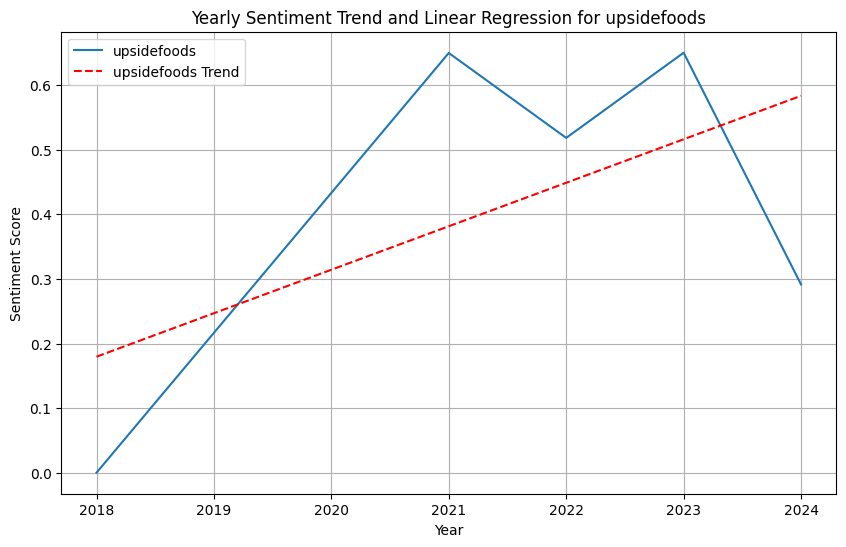

Regression analysis for impossiblefoods:
Slope: 0.017426108806934366
Intercept: -34.77125613558437
R-squared: 0.13703102242497855
P-value: 0.5396731899862599




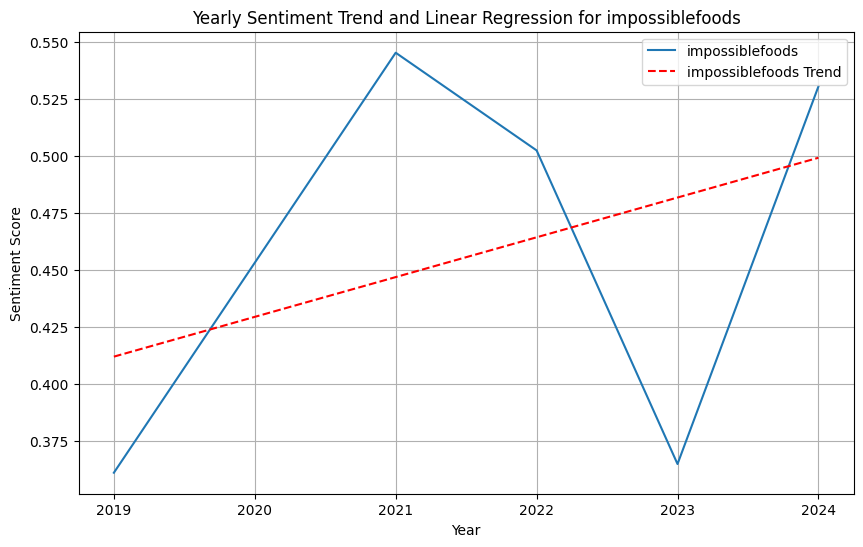

Regression analysis for beyondmeat:
Slope: -0.10977784282177865
Intercept: 222.63725503450513
R-squared: 0.7592745008330719
P-value: 0.32647237981013055




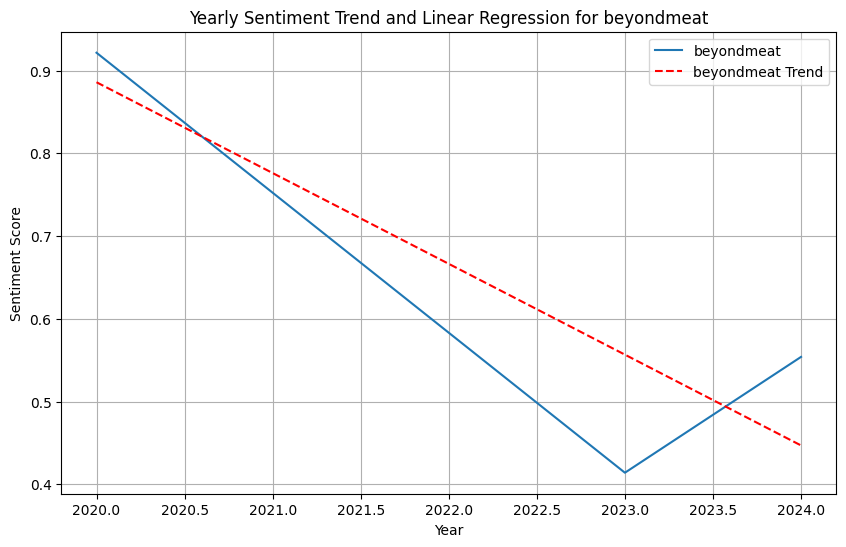

Regression analysis for alephfarms:
Slope: 0.16158827330287712
Intercept: -326.2016805241925
R-squared: 0.8136808350912793
P-value: 0.09795740949152104




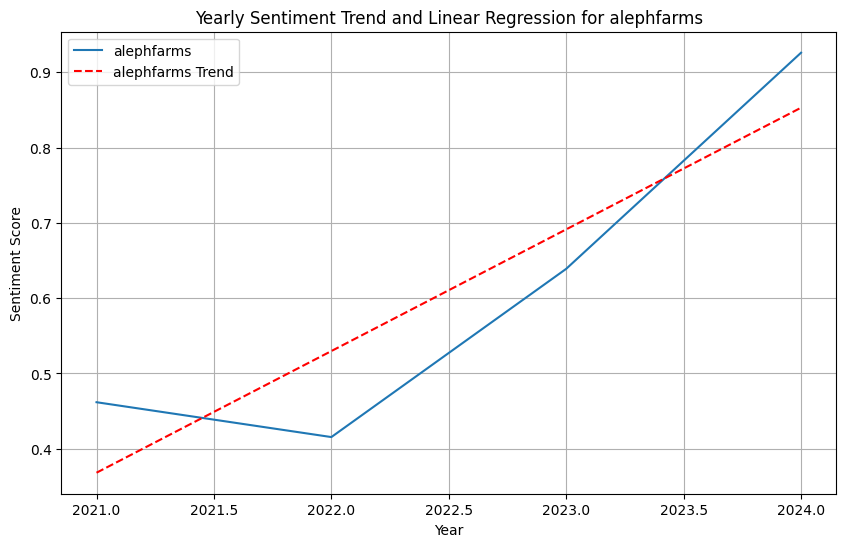

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 假设 df 是您的数据框，且 'date' 列包含日期，'Sentiment_Score' 列为情感得分
df['year'] = pd.to_datetime(df['date']).dt.year  # 提取年份

# 按年份和品牌分组，计算情感得分的平均值
sentiment_by_year = df.groupby(['year', 'brand'])['Sentiment_Score'].mean().reset_index()

# 绘制每个品牌的情感得分变化，并拟合线性回归模型
for brand in sentiment_by_year['brand'].unique():
    brand_data = sentiment_by_year[sentiment_by_year['brand'] == brand]

    # 准备数据
    X = brand_data[['year']]  # 年份作为特征
    X = sm.add_constant(X)  # 添加截距项
    y = brand_data['Sentiment_Score']  # 情感得分作为目标

    # 训练模型
    model = sm.OLS(y, X).fit()

    # 打印回归分析的结果
    print(f"Regression analysis for {brand}:")
    print(f"Slope: {model.params['year']}")
    print(f"Intercept: {model.params['const']}")
    print(f"R-squared: {model.rsquared}")
    print(f"P-value: {model.pvalues['year']}")
    print("\n")

    # 获取预测的情感得分
    y_pred = model.predict(X)

    # 绘制图表
    plt.figure(figsize=(10, 6))
    sns.lineplot(x='year', y='Sentiment_Score', data=brand_data, label=brand)  # 实际情感得分
    plt.plot(brand_data['year'], y_pred, label=f'{brand} Trend', linestyle='--', color='red')  # 线性回归趋势线
    plt.title(f'Yearly Sentiment Trend and Linear Regression for {brand}')
    plt.xlabel('Year')
    plt.ylabel('Sentiment Score')
    plt.legend()
    plt.grid(True)
    plt.show()



In [ ]:
# 保存每年每个品牌的情感得分
sentiment_by_year.to_csv('/content/drive/MyDrive/MDV/sentiment_by_year.csv', index=False)
print('Sentiment by year saved successfully!')


Sentiment by year saved successfully!


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


#LDA

In [ ]:
pip install pyLDAvis

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
import pandas as pd
import gensim
from gensim import corpora
import pyLDAvis
import pyLDAvis.gensim
import os
import importlib

# 确保 pyLDAvis 的模块被正确加载
importlib.reload(pyLDAvis)
importlib.reload(pyLDAvis.gensim)

# 加载数据
df = pd.read_csv('/content/drive/MyDrive/MDV/preprocessed_data.csv')

# 品牌列表
brands = ['beyondmeat', 'impossiblefoods', 'upsidefoods', 'alephfarms']

# 创建输出目录
output_dir = '/content/drive/MyDrive/MDV/LDA_vis'
os.makedirs(output_dir, exist_ok=True)

# 为每个品牌创建 LDA 可视化
for brand in brands:
    print(f"Processing {brand}...")

    # 过滤品牌标签并移除品牌名称
    brand_tags = df[df['brand'] == brand]['Processed_Tags']

    # 清洗数据，确保所有数据为字符串并移除空值
    brand_tags = brand_tags.dropna().astype(str)

    # 分词
    tokenized_tags = [tags.split() for tags in brand_tags]

    # 移除品牌名称（将品牌名称添加为停用词）
    cleaned_tags = [[word for word in tags if word.lower() != brand.lower()] for tags in tokenized_tags]

    # 创建词典和词袋
    dictionary = corpora.Dictionary(cleaned_tags)
    bow_corpus = [dictionary.doc2bow(tag) for tag in cleaned_tags]

    # 训练 LDA 模型
    lda_model = gensim.models.LdaModel(
        corpus=bow_corpus,
        id2word=dictionary,
        num_topics=5,  # 设置主题数
        random_state=42,
        passes=10
    )

    # 使用 pyLDAvis 创建可视化数据
    pyLDAvis.enable_notebook()
    vis = pyLDAvis.gensim.prepare(lda_model, bow_corpus, dictionary)

    # 保存 HTML 文件
    vis_file = os.path.join(output_dir, f"{brand}_lda_vis.html")
    pyLDAvis.save_html(vis, vis_file)
    print(f"Visualization saved for {brand} at {vis_file}")

    # 在 Notebook 中展示
    pyLDAvis.display(vis)







/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Processing beyondmeat...
Visualization saved for beyondmeat at /content/drive/MyDrive/MDV/LDA_vis/beyondmeat_lda_vis.html
Processing impossiblefoods...
Visualization saved for impossiblefoods at /content/drive/MyDrive/MDV/LDA_vis/impossiblefoods_lda_vis.html
Processing upsidefoods...
Visualization saved for upsidefoods at /content/drive/MyDrive/MDV/LDA_vis/upsidefoods_lda_vis.html
Processing alephfarms...
Visualization saved for alephfarms at /content/drive/MyDrive/MDV/LDA_vis/alephfarms_lda_vis.html


#토픽별 감성분석

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/usr/local/lib/python3.10/dist-packages/textblob/_text.py:218: DeprecationWarning: invalid escape sequence '\.'
  RE_ABBR1 = re.compile("^[A-Za-z]\.$")       # single letter, "T. De Smedt"
/usr/local/lib/python3.10/dist-packages/textblob/_text.py:219: DeprecationWarning: invalid escape sequence '\.'
  RE_ABBR2 = re.compile("^([A-Za-z]\.)+$")    # alternating letters, "U.S."


Processing beyondmeat...
Processing impossiblefoods...
Processing upsidefoods...
Processing alephfarms...
Sentiment scores saved!


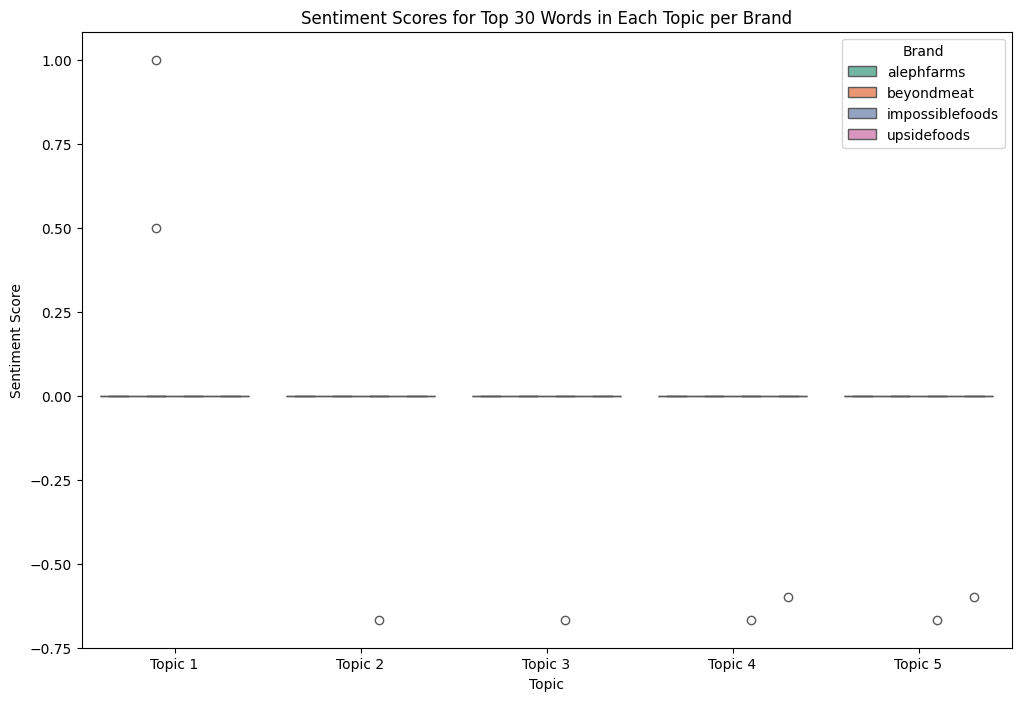

In [ ]:
import pandas as pd
import gensim
from gensim import corpora
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('/content/drive/MyDrive/MDV/preprocessed_data.csv')

# Brand list
brands = ['beyondmeat', 'impossiblefoods', 'upsidefoods', 'alephfarms']

# Store results
all_results = []

for brand in brands:
    print(f"Processing {brand}...")

    # Filter data for the brand
    brand_data = df[df['brand'] == brand]
    brand_tags = brand_data['Processed_Tags'].dropna().astype(str)

    # Tokenize tags and remove the brand name from the tags
    tokenized_tags = [tags.split() for tags in brand_tags]
    cleaned_tags = [[word for word in tags if word.lower() != brand.lower()] for tags in tokenized_tags]

    # Create a dictionary and a Bag-of-Words corpus
    dictionary = corpora.Dictionary(cleaned_tags)
    bow_corpus = [dictionary.doc2bow(tag) for tag in cleaned_tags]

    # Train the LDA model
    lda_model = gensim.models.LdaModel(
        corpus=bow_corpus,
        id2word=dictionary,
        num_topics=5,  # Change the number of topics if needed
        random_state=42,
        passes=10
    )

    # Get the top 30 words for each topic
    top_words_per_topic = {}
    for topic_id in range(lda_model.num_topics):
        top_words = lda_model.show_topic(topic_id, topn=30)
        top_words_per_topic[topic_id] = [word for word, _ in top_words]

    # Perform sentiment analysis for each top word
    sentiment_results = []
    for topic_id, top_words in top_words_per_topic.items():
        for word in top_words:
            blob = TextBlob(word)
            sentiment_score = blob.sentiment.polarity
            sentiment_results.append({
                'Brand': brand,
                'Topic': f'Topic {topic_id + 1}',  # Label topics as Topic 1, Topic 2, etc.
                'Word': word,
                'Sentiment_Score': sentiment_score
            })

    # Store results for the current brand
    brand_results = pd.DataFrame(sentiment_results)
    all_results.append(brand_results)

# Combine all results
final_results = pd.concat(all_results, ignore_index=True)

# Save results to CSV
final_results.to_csv('/content/drive/MyDrive/MDV/brand_sentiment_scores.csv', index=False)
print("Sentiment scores saved!")

# Visualization: Plot sentiment scores for each brand's topic
plt.figure(figsize=(12, 8))
final_results['Brand'] = pd.Categorical(final_results['Brand'])  # Ensure the 'Brand' column is categorical
sns.boxplot(x='Topic', y='Sentiment_Score', hue='Brand', data=final_results, palette='Set2')
plt.title('Sentiment Scores for Top 30 Words in Each Topic per Brand')
plt.xlabel('Topic')
plt.ylabel('Sentiment Score')
plt.legend(title='Brand')
plt.show()


In [ ]:
# 找出情感分数最高和最低的记录
max_sentiment = final_results.loc[final_results['Sentiment_Score'].idxmax()]
min_sentiment = final_results.loc[final_results['Sentiment_Score'].idxmin()]

# 输出
print("Max Sentiment Score: ", max_sentiment)
print("Min Sentiment Score: ", min_sentiment)


Max Sentiment Score:  Brand              beyondmeat
Topic                 Topic 1
Word                delicious
Sentiment_Score           1.0
Name: 26, dtype: object
Min Sentiment Score:  Brand              impossiblefoods
Topic                      Topic 2
Word                    impossible
Sentiment_Score          -0.666667
Name: 184, dtype: object


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
